In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns

# Simulation of a Modular BBM92 Receiver Subsystem

To ensure modularity and ease of integration with external tools, the system is designed as a pipeline of independent processing blocks. The data flow strictly separates the **"Quantum Source"** (Generation), the **"Channel"** (Transmission), and the **"Receiver"** (Detection and Processing), allowing for individual components to be swapped or upgraded without disrupting the system logic.

### Module 1: Input Source Module
This module creates the ground-truth data required to validate the receiver.

* **Function:** `gen_entangled_pairs(N)`
    * **Input:** Simulation Parameters (Number of pairs $N$, Entanglement Type).
    * **Logic:** Generates $N$ object pairs. To simulate entanglement logic in a classical environment, each object is assigned pre-correlated hidden variables for both Rectilinear (Z) and Diagonal (X) bases (e.g., if Alice has $Z=0$, Bob is pre-set to $Z=1$ for $\Psi^-$).
    * **Output:** A list of $N$ `QuantumPair` objects.

* **Function:** `assign_timestamps()`
    * **Input:** The generated `QuantumPair` list.
    * **Logic:** Assigns an initial emission time $t=0$ (or a scheduled sequence) to both photons in a pair, ensuring perfect synchronization ($t_A = t_B$) before channel effects are applied.
    * **Output:** Synchronized, timestamped photon list.

In [2]:
class Source:
    def __init__(self, n_pairs):
        self.n_pairs = n_pairs
    def gen_entangled_pairs(self):
        # Empty dict to hold pairs
        print("Generating", self.n_pairs, "entangled pairs...")
        pairs = []
        for i in range(self.n_pairs):
            # Create a QuantumPair with pre-correlated hidden variables
            pair = QuantumPair(pair_id=i)
            pairs.append(pair)
        return pairs

    def assign_timestamps(self, pairs, separation_ns=10, sequential_mode=True):

        # Useful for debugging with no time separation
        if sequential_mode == False:
            print("Assigning no time separation for debugging...")
            for pair in pairs:
                # Assign synchronized timestamps
                pair.timestamp_A = 0
                pair.timestamp_B = 0
        else:
            print("Assigning time separation of", separation_ns, "...")
            for pair in pairs:
                # Assign staggered timestamps
                pair.timestamp_A = pair.pair_id * separation_ns
                pair.timestamp_B = pair.pair_id * separation_ns
        return pairs

class QuantumPair:
    def __init__(self, pair_id):
        self.pair_id = pair_id
        # Randomly assign hidden variables for Z and X bases
        self.alice_Z = np.random.choice([0, 1])
        self.bob_Z = 1 - self.alice_Z  # Anti-correlated for Psi-
        self.alice_X = np.random.choice([0, 1])
        self.bob_X = 1 - self.alice_X  # Anti-correlated for Psi-
        self.timestamp_A = 0
        self.timestamp_B = 0

    def __repr__(self):
        # Print assignments
        return (f"Pair {self.pair_id}: "
                f"Alice(Z={self.alice_Z}, X={self.alice_X}, t={self.timestamp_A}), "
                f"Bob(Z={self.bob_Z}, X={self.bob_X}, t={self.timestamp_B})")

In [3]:
# Test the Source module
n_pairs = 10000
source = Source(n_pairs)
pairs = source.gen_entangled_pairs()
timestamped_pairs = source.assign_timestamps(pairs)
for pair in timestamped_pairs:
    print(pair)

Generating 10000 entangled pairs...
Assigning time separation of 10 ...
Pair 0: Alice(Z=0, X=1, t=0), Bob(Z=1, X=0, t=0)
Pair 1: Alice(Z=1, X=1, t=10), Bob(Z=0, X=0, t=10)
Pair 2: Alice(Z=1, X=0, t=20), Bob(Z=0, X=1, t=20)
Pair 3: Alice(Z=0, X=0, t=30), Bob(Z=1, X=1, t=30)
Pair 4: Alice(Z=0, X=1, t=40), Bob(Z=1, X=0, t=40)
Pair 5: Alice(Z=0, X=0, t=50), Bob(Z=1, X=1, t=50)
Pair 6: Alice(Z=0, X=0, t=60), Bob(Z=1, X=1, t=60)
Pair 7: Alice(Z=0, X=0, t=70), Bob(Z=1, X=1, t=70)
Pair 8: Alice(Z=0, X=0, t=80), Bob(Z=1, X=1, t=80)
Pair 9: Alice(Z=1, X=1, t=90), Bob(Z=0, X=0, t=90)
Pair 10: Alice(Z=0, X=1, t=100), Bob(Z=1, X=0, t=100)
Pair 11: Alice(Z=0, X=1, t=110), Bob(Z=1, X=0, t=110)
Pair 12: Alice(Z=0, X=0, t=120), Bob(Z=1, X=1, t=120)
Pair 13: Alice(Z=1, X=1, t=130), Bob(Z=0, X=0, t=130)
Pair 14: Alice(Z=1, X=0, t=140), Bob(Z=0, X=1, t=140)
Pair 15: Alice(Z=0, X=1, t=150), Bob(Z=1, X=0, t=150)
Pair 16: Alice(Z=1, X=1, t=160), Bob(Z=0, X=0, t=160)
Pair 17: Alice(Z=0, X=0, t=170), Bob(Z=1, 

### Module 2: Channel Interface (Mock Channel)
This module degrades the perfect signal to mimic satellite downlink conditions.

* **Function:** `apply_geometric_loss(dB)`
    * **Input:** Perfect photon list and a loss parameter (e.g., 40-60 dB).
    * **Logic:** Simulates diffraction-limited beam spreading. The function stochastically deletes photons from the list with a probability $P = 1 - 10^{-dB/10}$.
    * **Output:** A sparse list of surviving photons.

* **Function:** `add_turbulence_jitter(sigma)`
    * **Input:** Sparse photon list and sigma.
    * **Logic:** Adds random Gaussian noise to the arrival timestamps of surviving photons ($t_{final} = t_{initial} + \mathcal{N}(0, \sigma)$). This simulates path-length fluctuations caused by atmospheric turbulence.
    * **Output:** Jittered photon list.

In [4]:
class Channel:
    def __init__(self):
        pass

    def apply_geometric_loss(self, photon_list, loss_dB):
        print(f"Applying geometric loss of {loss_dB} dB...")
        survival_prob = 10 ** (-loss_dB / 10)
        surviving_photons = []
        for photon in photon_list:
            if np.random.rand() < survival_prob:
                surviving_photons.append(photon)
        print(f"Survived photons: {len(surviving_photons)} out of {len(photon_list)}")
        return surviving_photons

    def add_turbulence_jitter(self, photon_list, sigma_ns):
        print(f"Adding turbulence jitter with sigma = {sigma_ns} ns...")
        for photon in photon_list:
            jitter_A = np.random.normal(0, sigma_ns)
            jitter_B = np.random.normal(0, sigma_ns)
            photon.timestamp_A += jitter_A
            photon.timestamp_B += jitter_B
        return photon_list

# Test the Channel module
channel = Channel()
loss_dB = 10
sigma_ns = 1.0
surviving_photons = channel.apply_geometric_loss(timestamped_pairs, loss_dB)
jittered_photons = channel.add_turbulence_jitter(surviving_photons, sigma_ns)
for photon in jittered_photons:
    print(photon)

Applying geometric loss of 10 dB...
Survived photons: 1024 out of 10000
Adding turbulence jitter with sigma = 1.0 ns...
Pair 0: Alice(Z=0, X=1, t=-0.11309221257317915), Bob(Z=1, X=0, t=0.4774637255868438)
Pair 8: Alice(Z=0, X=0, t=78.24921988812038), Bob(Z=1, X=1, t=80.89420523267131)
Pair 22: Alice(Z=0, X=1, t=218.68648281208473), Bob(Z=1, X=0, t=220.43981991916795)
Pair 25: Alice(Z=0, X=0, t=249.6015920967594), Bob(Z=1, X=1, t=249.54748549846778)
Pair 27: Alice(Z=1, X=0, t=267.79198248718177), Bob(Z=0, X=1, t=270.2968814322858)
Pair 28: Alice(Z=0, X=0, t=279.7915801081831), Bob(Z=1, X=1, t=282.3704829729702)
Pair 32: Alice(Z=0, X=0, t=319.2886210092945), Bob(Z=1, X=1, t=321.60830970877436)
Pair 41: Alice(Z=1, X=1, t=407.73390039459406), Bob(Z=0, X=0, t=409.3245761254736)
Pair 47: Alice(Z=1, X=0, t=470.03841359057685), Bob(Z=0, X=1, t=469.42514462181197)
Pair 60: Alice(Z=1, X=0, t=599.0551011519785), Bob(Z=0, X=1, t=599.9930598751214)
Pair 77: Alice(Z=0, X=0, t=769.257470175631), Bob(

### Module 3: Receiver Subsystem (Detector Hardware)
This module simulates the physical response of the optical ground station.

* **Function:** `efficiency_filter(eta)`
    * **Input:** Jittered photon list and efficiency $\eta$.
    * **Logic:** Simulates detector inefficiency. A photon is only registered if a random variable check exceeds the detector efficiency threshold ($\eta \approx 60\%$ for Si-APDs).
    * **Output:** Detected photon list.

* **Function:** `inject_dark_counts(Hz)`
    * **Input:** Simulation duration and rate parameter.
    * **Logic:** Injects false detection events into the data stream based on Poissonian statistics. The rate is set to $\approx 100$ Hz to model SNSPD performance.
    * **Output:** Noisy photon list (Signal + Noise).

* **Function:** `measure_basis()`
    * **Input:** The noisy photon list.
    * **Logic:** Simulates passive basis selection. Each event is randomly assigned to the Z or X basis (50/50 probability).
    * **Output:** Two independent Detection Logs (Alice and Bob) containing: `[Timestamp, Basis, Bit_Value]`.

In [5]:
class Receiver:
    def __init__(self):
        pass

    def efficiency_filter(self, photon_list, eta):
        print(f"Applying detector efficiency filter with eta = {eta}...")
        detected_photons = []
        for photon in photon_list:
            if np.random.rand() < eta:
                detected_photons.append(photon)
        print(f"   Detected: {len(detected_photons)} out of {len(photon_list)}")
        return detected_photons

    def inject_dark_counts(self, photon_list, duration_s, dark_count_rate_Hz):
        print(f"Injecting dark counts at rate = {dark_count_rate_Hz} Hz over {duration_s} s...")
        n_dark_counts = np.random.poisson(dark_count_rate_Hz * duration_s)
        print(f"   Injected {n_dark_counts} dark counts.")
        for _ in range(n_dark_counts):
            # Create a fake photon with random timestamp within duration
            fake_photon = QuantumPair(pair_id=-1)  # -1 indicates dark count
            fake_photon.timestamp_A = np.random.uniform(0, duration_s * 1e9)  # in ns
            fake_photon.timestamp_B = np.random.uniform(0, duration_s * 1e9)  # in ns
            photon_list.append(fake_photon)
        return photon_list

    def measure_basis(self, photon_list):
        print("Measuring basis for detected photons...")
        detection_log_A = []
        detection_log_B = []
        for photon in photon_list:
            # Randomly assign basis
            basis_A = np.random.choice(['Z', 'X'])
            basis_B = np.random.choice(['Z', 'X'])

            # Determine bit value based on hidden variables and basis
            if basis_A == 'Z':
                bit_value_A = photon.alice_Z
            else:
                bit_value_A = photon.alice_X

            if basis_B == 'Z':
                bit_value_B = photon.bob_Z
            else:
                bit_value_B = photon.bob_X

            detection_log_A.append([photon.timestamp_A, basis_A, bit_value_A])
            detection_log_B.append([photon.timestamp_B, basis_B, bit_value_B])

        return DetectionResult(detection_log_A, detection_log_B)


class DetectionResult:
    def __init__(self, log_A, log_B):
        # Store the raw data
        self.log_A = log_A
        self.log_B = log_B

    def __repr__(self):
        # Create Header
        header = f"\n{'Alice Detection Log':<35} | {'Bob Detection Log':<35}\n"
        divider = "-" * 75 + "\n"
        columns = f"{'Time (ns)':<12} {'Basis':<8} {'Bit':<5}     | {'Time (ns)':<12} {'Basis':<8} {'Bit':<5}\n"

        output = header + divider + columns + divider

        # Sort data by timestamp (to handle random dark counts correctly)
        sorted_A = sorted(self.log_A, key=lambda x: x[0])
        sorted_B = sorted(self.log_B, key=lambda x: x[0])

        # Build the rows
        # We limit the print to 15 lines so it doesn't flood the console
        limit = 15
        count = min(limit, len(sorted_A))

        for i in range(count):
            row_A = sorted_A[i]
            row_B = sorted_B[i]

            # Format: Time (1 decimal), Basis, Bit
            str_A = f"{row_A[0]:<12.1f} {row_A[1]:<8} {row_A[2]:<5}"
            str_B = f"{row_B[0]:<12.1f} {row_B[1]:<8} {row_B[2]:<5}"

            output += f"{str_A}     | {str_B}\n"

        # Footer info
        if len(sorted_A) > limit:
            output += f"... ({len(sorted_A) - limit} more entries hidden) ...\n"

        return output

# Test the Receiver module
receiver = Receiver()
filtered = receiver.efficiency_filter(jittered_photons, eta=0.6)
noisy = receiver.inject_dark_counts(filtered, duration_s=1.0, dark_count_rate_Hz=50)

results = receiver.measure_basis(noisy)

print(results)

Applying detector efficiency filter with eta = 0.6...
   Detected: 631 out of 1024
Injecting dark counts at rate = 50 Hz over 1.0 s...
   Injected 45 dark counts.
Measuring basis for detected photons...

Alice Detection Log                 | Bob Detection Log                  
---------------------------------------------------------------------------
Time (ns)    Basis    Bit       | Time (ns)    Basis    Bit  
---------------------------------------------------------------------------
78.2         Z        0         | 80.9         X        1    
218.7        X        1         | 220.4        Z        1    
267.8        X        0         | 270.3        X        1    
319.3        X        0         | 321.6        Z        1    
407.7        Z        1         | 409.3        X        0    
599.1        X        0         | 600.0        Z        0    
769.3        X        0         | 769.9        Z        1    
808.6        X        0         | 809.6        Z        1    
859.3       

### Module 4: Receiver Subsystem (Processing Logic)
This component performs the classical algorithms required to extract the key.

* **Function:** `find_coincidences(tau_c)`
    * **Input:** The two independent Detection Logs.
    * **Logic:** Scans both logs to identify pairs where $|t_A - t_B| < \tau_c$. The window $\tau_c$ (typically 1-2 ns) is critical for distinguishing signal from noise.
    * **Output:** List of Raw Coincidences.

* **Function:** `sift_keys()`
    * **Input:** List of Raw Coincidences.
    * **Logic:** Compares the basis choice of Alice and Bob for each coincidence. Discards events where bases are incompatible.
    * **Output:** Sifted Key.

* **Function:** `calc_QBER()`
    * **Input:** The Sifted Key.
    * **Logic:** Compares the bit values of the sifted key. Calculates the ratio of errors to total bits.
    * **Output:** Final QBER percentage and Secure Key Rate.

In [6]:
class Processor:
    def __init__(self):
        pass

    def find_coincidences(self, log_A, log_B, tau_c_ns):
        print(f"--- Processor: Finding Coincidences (Window = {tau_c_ns} ns) ---")

        # Sort logs by time to ensure sequential processing
        log_A.sort(key=lambda x: x[0])
        log_B.sort(key=lambda x: x[0])

        coincidences = []
        index_B = 0
        len_B = len(log_B)

        for event_A in log_A:
            t_A = event_A[0]
            # Move sliding window start
            while index_B < len_B and log_B[index_B][0] < t_A - tau_c_ns:
                index_B += 1

            # Scan specific window range
            for j in range(index_B, len_B):
                event_B = log_B[j]
                t_B = event_B[0]

                if t_B > t_A + tau_c_ns:
                    break

                # Precise coincidence check
                if abs(t_A - t_B) <= tau_c_ns:
                    coincidences.append((event_A, event_B))

        print(f"   Found {len(coincidences)} raw coincidences.")
        return coincidences

    def sift_keys(self, coincidences):
        print("--- Processor: Sifting Keys ---")
        sifted_key = []

        for event_A, event_B in coincidences:
            basis_A = event_A[1]
            basis_B = event_B[1]

            # Keep only events where bases match
            if basis_A == basis_B:
                bit_A = event_A[2]
                bit_B = event_B[2]

                # Psi- Correction: Bob flips bit to match Alice
                bit_B = 1 - bit_B

                sifted_key.append((bit_A, bit_B))

        print(f"   Sifted Key Length: {len(sifted_key)} bits")
        return sifted_key

    def calc_QBER(self, sifted_key, duration_s, dark_rate_A=0, dark_rate_B=0, coincidence_window_ns=1.5):
        print("--- Processor: Calculating QBER (Hybrid Model) ---")

        # The Signal (From Simulation)
        signal_bits = len(sifted_key)
        # Count errors in the simulation (should be 0 for ideal entanglement)
        signal_errors = sum(1 for bA, bB in sifted_key if bA != bB)

        # The Noise (Analytical)
        # Calculate expected accidental coincidences (Noise Floor)
        # Formula: Rate_A * Rate_B * Window * Duration
        window_s = coincidence_window_ns * 1e-9

        # Raw accidental rate (Hz)
        accidental_rate_hz = dark_rate_A * dark_rate_B * window_s

        # Apply Sifting (50% chance noise matches basis)
        noise_bits = (accidental_rate_hz * duration_s) / 2.0

        # Apply Error Probability (50% chance noise causes bit mismatch)
        noise_errors = noise_bits / 2.0

        # Combine Components
        total_bits = signal_bits + noise_bits
        total_errors = signal_errors + noise_errors

        # Calculate Final Metrics
        if total_bits == 0:
            print("   No bits (Signal or Noise). Rate is 0.")
            return 0.0, 0.0

        QBER = total_errors / total_bits

        # Secure Key Rate (using Binary Entropy)
        # Rate = (Total_Bits / Duration) * [1 - 2*h(Q)]
        if QBER >= 0.11: # Standard Security Threshold ~11%
            secure_fraction = 0.0
        else:
            if QBER > 0:
                h_QBER = -QBER * math.log2(QBER) - (1 - QBER) * math.log2(1 - QBER)
            else:
                h_QBER = 0
            secure_fraction = 1 - (2 * h_QBER)

        raw_rate_bps = total_bits / duration_s
        secure_key_rate = raw_rate_bps * max(0, secure_fraction)

        print(f"   Analysis: Signal={signal_bits} | Expected Noise={noise_bits:.2f}")
        print(f"   QBER: {QBER:.2%} | Secure Rate: {secure_key_rate:.2f} bps")

        return QBER, secure_key_rate

### Results
First we run a test where we should get a low QBER and a non-zero secure key rate, to make sure the scripts performs as expected.

In [7]:

# --- SETUP PARAMETERS ---
SIM_PARAMS = {
    "N_PAIRS": 5000,          # Enough statistics to get a stable QBER
    "LOSS_DB": 3.0,           # 3 dB loss (50% survival) - Realistic for fiber/short free-space
    "JITTER_NS": 0.5,         # 0.5 ns turbulence jitter
    "EFFICIENCY": 0.8,        # 80% detector efficiency
    "DARK_COUNT_HZ": 500,     # 500 Hz dark count rate
    "PULSE_RATE_MHZ": 100,    # 100 MHz source (10ns separation)
    "COINCIDENCE_WINDOW": 1.5 # 1.5 ns matching window
}

def run_system_test():
    print("================================================================")
    print("      BBM92 SYSTEM INTEGRATION TEST")
    print("================================================================")

    # --- STEP 1: SOURCE ---
    # Initialize Source with N pairs
    source = Source(n_pairs=SIM_PARAMS["N_PAIRS"])

    # Generate Objects
    pairs = source.gen_entangled_pairs()

    # Assign Time (Sequential Mode to simulate real duration)
    period = 1000.0 / SIM_PARAMS["PULSE_RATE_MHZ"] # 10ns
    pairs = source.assign_timestamps(pairs, separation_ns=period, sequential_mode=True)

    # Calculate Simulation Duration
    duration = (SIM_PARAMS["N_PAIRS"] * period) * 1e-9 # Convert ns to seconds
    print(f"\n[1] SOURCE GENERATED")
    print(f"    Pairs: {len(pairs)}")
    print(f"    Simulated Duration: {duration:.6f} seconds")

    # --- STEP 2: CHANNEL ---
    channel = Channel()

    # Apply Geometric Loss
    surviving_pairs = channel.apply_geometric_loss(pairs, loss_dB=SIM_PARAMS["LOSS_DB"])

    # Apply Turbulence Jitter
    jittered_pairs = channel.add_turbulence_jitter(surviving_pairs, sigma_ns=SIM_PARAMS["JITTER_NS"])

    # --- STEP 3: RECEIVER ---
    receiver = Receiver()

    # Efficiency Filter
    detected_photons = receiver.efficiency_filter(jittered_pairs, eta=SIM_PARAMS["EFFICIENCY"])

    # Inject Noise (Dark Counts)
    noisy_photons = receiver.inject_dark_counts(detected_photons, duration, SIM_PARAMS["DARK_COUNT_HZ"])

    # Measure (This returns the DetectionResult object)
    # Note: We access the raw logs from the result object for the processor
    result_obj = receiver.measure_basis(noisy_photons)
    print(f"\n[3] RECEIVER MEASUREMENT COMPLETE")
    print(result_obj) # This uses your professional __repr__!

    # --- STEP 4: PROCESSOR ---
    processor = Processor()

    # Find Coincidences
    coincidences = processor.find_coincidences(
        result_obj.log_A,
        result_obj.log_B,
        tau_c_ns=SIM_PARAMS["COINCIDENCE_WINDOW"]
    )

    # Sift Keys
    sifted_keys = processor.sift_keys(coincidences)

    # Calc QBER & Rate
    qber, rate = processor.calc_QBER(sifted_keys, duration)

    print("\n================================================================")
    print("      FINAL RESULTS VERIFICATION")
    print("================================================================")
    print(f"Expected Pairs (approx): {SIM_PARAMS['N_PAIRS'] * (10**(-3/10)) * 0.8 * 0.8:.0f}")
    print(f"Actual Coincidences:     {len(coincidences)}")
    print(f"Sifted Key Length:       {len(sifted_keys)}")
    print(f"QBER:                    {qber:.2%} (Should be < 1% for this ideal test)")
    print(f"Final Key Rate:          {rate:.2f} bps")

    if rate > 0:
        print("Secure key generated successfully.")
    else:
        print("No secure key. Check parameters.")

# Run the test
run_system_test()

      BBM92 SYSTEM INTEGRATION TEST
Generating 5000 entangled pairs...
Assigning time separation of 10.0 ...

[1] SOURCE GENERATED
    Pairs: 5000
    Simulated Duration: 0.000050 seconds
Applying geometric loss of 3.0 dB...
Survived photons: 2508 out of 5000
Adding turbulence jitter with sigma = 0.5 ns...
Applying detector efficiency filter with eta = 0.8...
   Detected: 1995 out of 2508
Injecting dark counts at rate = 500 Hz over 5e-05 s...
   Injected 0 dark counts.
Measuring basis for detected photons...

[3] RECEIVER MEASUREMENT COMPLETE

Alice Detection Log                 | Bob Detection Log                  
---------------------------------------------------------------------------
Time (ns)    Basis    Bit       | Time (ns)    Basis    Bit  
---------------------------------------------------------------------------
-0.3         Z        0         | 0.0          Z        1    
10.4         Z        0         | 9.7          Z        1    
30.2         X        1         | 29.8

Now that we have verified the system works end-to-end, we can run a comparative analysis between two hardware scenarios: Si-APD vs SNSPD.

In [12]:

# ==============================================================================
# CONFIGURATION
# ==============================================================================

# Common Parameters
N_SIM_PAIRS = 200000
PULSE_RATE_MHZ = 100
WINDOW_NS = 1.5

# Hardware Scenarios
CONFIG_SI_APD = {
    "LABEL": "Option A: Si-APD (Micius)",
    "EFFICIENCY": 0.60,
    "DARK_COUNT_HZ": 2000,
    "COLOR": "red", "MARKER": "o"
}

CONFIG_SNSPD = {
    "LABEL": "Option B: SNSPD (Future)",
    "EFFICIENCY": 0.90,
    "DARK_COUNT_HZ": 100,
    "COLOR": "blue", "MARKER": "s"
}

loss_values = [20, 25, 30, 35, 40, 45, 50, 55, 60]
results = {"si_apd": {"rate": [], "qber": []}, "snspd": {"rate": [], "qber": []}}

# ==============================================================================
# SIMULATION LOOP
# ==============================================================================
print("Starting Comparative Analysis...")

for loss in loss_values:
    # Run simulation for each loss value
    source = Source(n_pairs=N_SIM_PAIRS)
    pairs = source.gen_entangled_pairs()
    period = 1000.0 / PULSE_RATE_MHZ
    pairs = source.assign_timestamps(pairs, separation_ns=period, sequential_mode=True)

    # Channel Effects
    channel = Channel()
    surviving = channel.apply_geometric_loss(pairs, loss_dB=loss)
    jittered = channel.add_turbulence_jitter(surviving, sigma_ns=0.5)

    # Receiver & Processor Instances
    receiver = Receiver()
    processor = Processor()

    # Function to process a specific config
    def process_config(config):
        # Hardware Simulation
        detected = receiver.efficiency_filter(jittered, eta=config["EFFICIENCY"])
        measured = receiver.measure_basis(detected)

        # Logic Processing
        coincidences = processor.find_coincidences(measured.log_A, measured.log_B, tau_c_ns=WINDOW_NS)
        sifted_keys = processor.sift_keys(coincidences)

        # Scaling to 1 Second
        # We need to pass the "Equivalent 1-Second Signal" to the processor
        # Simulation duration = N * period
        sim_duration = N_SIM_PAIRS * period * 1e-9
        scale_to_1s = 1.0 / sim_duration

        # We multiply the list of keys to represent 1 second of data
        scaled_signal = sifted_keys * int(scale_to_1s)

        # Calculate Metrics
        q, r = processor.calc_QBER(
            sifted_key=scaled_signal,
            duration_s=1.0,  # We are analyzing a standardized 1.0s window
            dark_rate_A=config["DARK_COUNT_HZ"],
            dark_rate_B=config["DARK_COUNT_HZ"],
            coincidence_window_ns=WINDOW_NS
        )
        return q, r

    # Run Option A
    q_a, r_a = process_config(CONFIG_SI_APD)
    results["si_apd"]["qber"].append(q_a)
    results["si_apd"]["rate"].append(r_a)

    # Run Option B
    q_b, r_b = process_config(CONFIG_SNSPD)
    results["snspd"]["qber"].append(q_b)
    results["snspd"]["rate"].append(r_b)

print ("Simulations finished")

Starting Comparative Analysis...
Generating 200000 entangled pairs...
Assigning time separation of 10.0 ...
Applying geometric loss of 20 dB...
Survived photons: 2030 out of 200000
Adding turbulence jitter with sigma = 0.5 ns...
Applying detector efficiency filter with eta = 0.6...
   Detected: 1183 out of 2030
Measuring basis for detected photons...
--- Processor: Finding Coincidences (Window = 1.5 ns) ---
   Found 1134 raw coincidences.
--- Processor: Sifting Keys ---
   Sifted Key Length: 565 bits
--- Processor: Calculating QBER (Hybrid Model) ---
   Analysis: Signal=282500 | Expected Noise=0.00
   QBER: 0.00% | Secure Rate: 282499.92 bps
Applying detector efficiency filter with eta = 0.9...
   Detected: 1858 out of 2030
Measuring basis for detected photons...
--- Processor: Finding Coincidences (Window = 1.5 ns) ---
   Found 1787 raw coincidences.
--- Processor: Sifting Keys ---
   Sifted Key Length: 898 bits
--- Processor: Calculating QBER (Hybrid Model) ---
   Analysis: Signal=44

Graphs saved successfully as 'comparative_results.pdf'


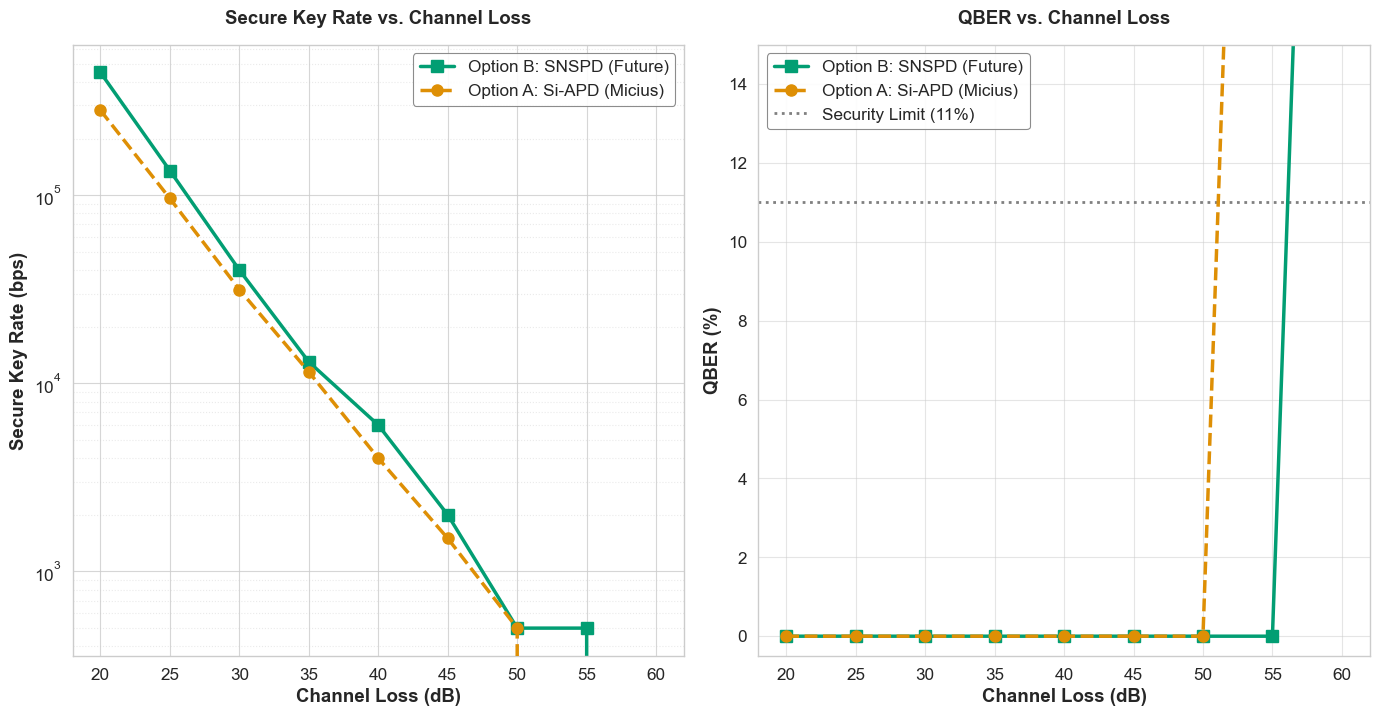

In [13]:
# Plotting
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
colors = sns.color_palette("colorblind")

col_A = colors[1] # Option A (Ochre)
col_B = colors[2] # Option B (Teal)

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# --- PLOT 1: SECURE KEY RATE ---
# zorder=2 for solid line (bottom), zorder=3 for dashed line (top)
ax1.semilogy(loss_values, results["snspd"]["rate"],
             color=col_B, marker='s', markersize=8, linewidth=2.5,
             label=CONFIG_SNSPD["LABEL"], linestyle='-', zorder=2)

ax1.semilogy(loss_values, results["si_apd"]["rate"],
             color=col_A, marker='o', markersize=8, linewidth=2.5,
             label=CONFIG_SI_APD["LABEL"], linestyle='--', zorder=3)

ax1.set_title("Secure Key Rate vs. Channel Loss", fontweight='bold', pad=15)
ax1.set_xlabel("Channel Loss (dB)", fontweight='bold')
ax1.set_ylabel("Secure Key Rate (bps)", fontweight='bold')
ax1.legend(frameon=True, framealpha=0.9, edgecolor='gray', fancybox=True)
ax1.grid(True, which="major", linestyle='-', alpha=0.8)
ax1.grid(True, which="minor", linestyle=':', alpha=0.4)
ax1.set_box_aspect(1)

# --- PLOT 2: QBER ---
qber_si = [q * 100 for q in results["si_apd"]["qber"]]
qber_snspd = [q * 100 for q in results["snspd"]["qber"]]

# Plot solid line (Option B) first (lower layer)
ax2.plot(loss_values, qber_snspd,
         color=col_B, marker='s', markersize=8, linewidth=2.5,
         label=CONFIG_SNSPD["LABEL"], linestyle='-', zorder=2)

# Plot dashed line (Option A) second (higher layer) so it sits on top
ax2.plot(loss_values, qber_si,
         color=col_A, marker='o', markersize=8, linewidth=2.5,
         label=CONFIG_SI_APD["LABEL"], linestyle='--', zorder=3)

# Security Threshold Line
ax2.axhline(y=11.0, color='gray', linestyle=':', linewidth=2, label="Security Limit (11%)", zorder=1)

ax2.set_title("QBER vs. Channel Loss", fontweight='bold', pad=15)
ax2.set_xlabel("Channel Loss (dB)", fontweight='bold')
ax2.set_ylabel("QBER (%)", fontweight='bold')

ax2.set_ylim(-0.5, 15)

ax2.legend(frameon=True, framealpha=0.9, edgecolor='gray', fancybox=True)
ax2.grid(True, alpha=0.5)
ax2.set_box_aspect(1)

# --- SAVE ---
plt.tight_layout()
plt.savefig("comparative_results.pdf", format='pdf', bbox_inches='tight')
print("Graphs saved successfully as 'comparative_results.pdf'")

As we can see the secure key rate drops exponentially with loss, but the SNSPD configuration maintains a non-zero key rate even at high losses (up to 55 dB), while the Si-APD configuration fails to produce a secure key beyond ~45 dB. The QBER remains below the security threshold for both configurations at lower losses, but the Si-APD configuration exceeds the limit as loss increases, while the SNSPD configuration stays within acceptable limits for a wider range of conditions. This analysis highlights the advantages of using advanced detector technology in satellite-based QKD systems.